Exercice 2

In [30]:
#import dtale
import numpy as np
from scipy.optimize import curve_fit
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [31]:
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Historical archive endpoint
url = "https://archive-api.open-meteo.com/v1/era5"

# Amsterdam
params = {
    "latitude": 52.37,
    "longitude": 4.89,
    "start_date": "2016-01-01",
    "end_date": "2026-02-01",
    "hourly": "temperature_2m",
    "daily": "temperature_2m_mean"
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

print(f"Elevation: {response.Elevation()} m")
print(f"Timezone: {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"UTC Offset (s): {response.UtcOffsetSeconds()}")

# Hourly data
hourly = response.Hourly()
hourly_temp = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "temperature_2m": hourly_temp
}
hourly_dataframe = pd.DataFrame(data=hourly_data)

# Daily data
daily = response.Daily()
daily_temp_mean = daily.Variables(0).ValuesAsNumpy()

daily_data = {
    "date": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ),
    "temperature_2m_mean": daily_temp_mean
}
daily_dataframe = pd.DataFrame(data=daily_data)

print("\nHourly data:")
print(hourly_dataframe.head())

print("\nDaily data:")
print(daily_dataframe.head())

Elevation: 11.0 m
Timezone: None None
UTC Offset (s): 0

Hourly data:
                       date  temperature_2m
0 2016-01-01 00:00:00+00:00           7.022
1 2016-01-01 01:00:00+00:00           7.522
2 2016-01-01 02:00:00+00:00           7.722
3 2016-01-01 03:00:00+00:00           7.372
4 2016-01-01 04:00:00+00:00           6.872

Daily data:
                       date  temperature_2m_mean
0 2016-01-01 00:00:00+00:00             6.411582
1 2016-01-02 00:00:00+00:00             5.680333
2 2016-01-03 00:00:00+00:00             6.922001
3 2016-01-04 00:00:00+00:00             5.153250
4 2016-01-05 00:00:00+00:00             5.599083


In [32]:
daily_dataframe['date'] = pd.to_datetime(daily_dataframe['date']).dt.normalize()

daily_dataframe = daily_dataframe.drop_duplicates(subset=['date'])
daily_dataframe = daily_dataframe.set_index('date')
daily_dataframe = daily_dataframe.asfreq('D') 

#We can already see that there are non nand values in temperature with dtale, however to follow the steps rigorously we coded the parts to count and interpolate the nands 
is_nan = daily_dataframe['temperature_2m_mean'].isna()
nan_groups = is_nan.ne(is_nan.shift()).cumsum()
nan_group_sizes = is_nan.groupby(nan_groups).transform('sum')
interpolated = daily_dataframe['temperature_2m_mean'].interpolate(method='linear')
daily_dataframe['temperature_2m_mean'] = np.where(is_nan & (nan_group_sizes <= 2), interpolated, daily_dataframe['temperature_2m_mean'])


daily_dataframe = daily_dataframe.reset_index()
daily_dataframe['date'] = daily_dataframe['date'].dt.strftime('%Y-%m-%d')

daily_dataframe.to_csv('cleaned_daily_temperature.csv', index=False)



In [33]:
#d= dtale.show(daily_dataframe)
#d.open_browser()

2.4  Estimation and Calibration of the Model under P 

In [34]:
##Task_1

# Defining the dataframes for training and testing
df_daily=pd.read_csv('cleaned_daily_temperature.csv')
df_daily['date']=pd.to_datetime(df_daily['date'])
df_training_daily=df_daily[df_daily['date']<='2024-12-31'].copy()
df_test_daily=df_daily[df_daily['date']>= '2025-01-01'].copy()

def model_fit(x, a, b, a1, b1):
    omega = 2 * np.pi / 365.25
    return a + b * x + a1 * np.cos(omega * x) + b1 * np.sin(omega * x)


first_ord = df_daily['date'].iloc[0].toordinal()

#Finding the parameters with training data
xdata_train = np.array([d.toordinal() - first_ord for d in df_training_daily['date']])
ydata_train = df_training_daily['temperature_2m_mean'].to_numpy()
params, cov = curve_fit(model_fit, xdata_train, ydata_train, method="lm")

#adding the estimator and the residuals to all the data
xdata_full = np.array([d.toordinal() - first_ord for d in df_daily['date']])
df_daily['mu_hat'] = model_fit(xdata_full,params[0],params[1],params[2],params[3])
df_daily['residual'] = df_daily['temperature_2m_mean'] - df_daily['mu_hat']

In [35]:
##Task_2

#Linear regression
df_training_daily = df_daily[df_daily['date'] <= '2024-12-31'].copy() #we add the columns mu_hat and residuals
df_training_daily['ytd_res']=df_training_daily['residual'].shift()

model="residual ~ ytd_res-1"
model_df = smf.ols(formula=model, data=df_training_daily).fit()
print(model_df.summary())


phi_hat = model_df.params['ytd_res']
kappa_hat = -np.log(phi_hat)
innovation_std = model_df.resid.std()


print(f"Phi_hat        : {phi_hat}")
print(f"kappa_hat      : {kappa_hat}")
print(f"Innovation_Std : {innovation_std}")
print(f"AIC            : {model_df.aic}")
print(f"BIC            : {model_df.bic}")

                                 OLS Regression Results                                
Dep. Variable:               residual   R-squared (uncentered):                   0.629
Model:                            OLS   Adj. R-squared (uncentered):              0.629
Method:                 Least Squares   F-statistic:                              5570.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):                        0.00
Time:                        20:13:49   Log-Likelihood:                         -6607.1
No. Observations:                3287   AIC:                                  1.322e+04
Df Residuals:                    3286   BIC:                                  1.322e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Fitted Volatility Parameters: [ 1.74581348e+00  1.48900100e-05  6.23982374e-02  2.38724282e-01
 -1.33495110e-01  1.45098256e-01]
RMSE for Volatility: 0.2934


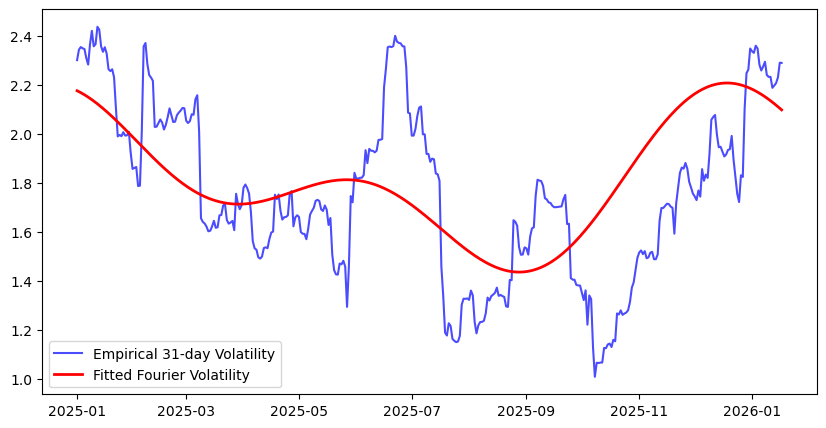

In [36]:
##Task 3
#1. We compute the residuasl
df_daily['epsilon_hat'] = df_daily['residual'] - phi_hat * df_daily['residual'].shift(1)
#2. Empirical volatily
df_daily['vol_empirical'] = df_daily['epsilon_hat'].rolling(window=31, center=True).std()


#3.Fourier volatility model
def fourier_vol(t, v0, v1, c1, d1, c2, d2):
    omega = 2 * np.pi / 365.25
    return v0 + v1*t + c1*np.sin(omega*t) + d1*np.cos(omega*t) + c2*np.sin(2*omega*t) + d2*np.cos(2*omega*t)

df_train_vol = df_daily[df_daily['date'] <= '2024-12-31'].dropna(subset=['vol_empirical'])

x_train_vol = np.array([d.toordinal() - first_ord for d in df_train_vol['date']])
y_train_vol = df_train_vol['vol_empirical'].to_numpy()
vol_params, _  = curve_fit(fourier_vol, x_train_vol, y_train_vol)

print(f"Fitted Volatility Parameters: {(vol_params)}")

x_full = np.array([d.toordinal() - first_ord for d in df_daily['date']])
df_daily['vol_fitted'] = fourier_vol(x_full, *vol_params)

#4
df_test_vol = df_daily[df_daily['date'] >= '2025-01-01'].copy()
df_test_vol = df_test_vol.dropna(subset=['vol_empirical'])
rmse_sigma = np.sqrt(np.mean((df_test_vol['vol_fitted'] - df_test_vol['vol_empirical'])**2))

print(f"RMSE for Volatility: {rmse_sigma:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(df_test_vol['date'], df_test_vol['vol_empirical'], label='Empirical 31-day Volatility', color='blue', alpha=0.7)
plt.plot(df_test_vol['date'], df_test_vol['vol_fitted'], label='Fitted Fourier Volatility', color='red', linewidth=2)
plt.legend()

## 2.5  Pricing of Weather Derivatives

In [ ]:
contracts   = pd.read_csv('contract_specifications.csv', parse_dates=['valuation_date','start_date','end_date'])
max_end     = contracts['end_date'].max()

VALUATION_DATE = pd.Timestamp('2024-12-31')
SIM_START = pd.Timestamp('2025-01-01')  
M_PATHS = 10_000
SEED = 67


# starting residual at val date
X0 = df_daily.loc[df_daily['date'] == VALUATION_DATE, 'residual'].values[0]
print(f"Starting residual X0 at {VALUATION_DATE.date()}: {X0:.4f}")


def simulate_paths(end_date, X0, M=M_PATHS, seed=SEED):
    """
    Simulate M temperature paths from SIM_START through end_date using
    the calibrated AR(1) + seasonal mean + Fourier volatility model.

    Variance reduction: antithetic variates — M/2 base draws Z are paired
    with their mirrors -Z, yielding M paths from M/2 random draws. M must be even.

    Returns:
    T : ndarray, shape (M, n_days)  — simulated daily temperatures
    dates : DatetimeIndex, length n_days
    """
    
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start=SIM_START, end=end_date, freq='D')
    n = len(dates)

    x_ord = np.array([d.toordinal() - first_ord for d in dates])
    mu = model_fit(x_ord, *params)                          # (n,)
    
    # truncate neg vlaues
    sigma = np.maximum(fourier_vol(x_ord, *vol_params), 1e-6) 

    # antithetic variables as variance reduction method
    Z_half = rng.standard_normal((M // 2, n))
    Z = np.concatenate([Z_half, -Z_half], axis=0)  # (M, n)
    
    X = np.empty((M, n))
    
    # init conditions
    X[:, 0] = phi_hat * X0 + sigma[0] * Z[:, 0]
    
    #AR(1)
    for i in range(1, n):
        X[:, i] = phi_hat * X[:, i - 1] + sigma[i] * Z[:, i]

    T = mu[np.newaxis, :] + X   # make (M, n)
    return T, dates


print(f"Simulating {M_PATHS:,} paths (antithetic) from {SIM_START.date()} → {max_end.date()} …")
T_all, dates_all = simulate_paths(max_end, X0)
print(f"Done — path matrix shape: {T_all.shape}")

Starting residual X0 at 2024-12-31: 1.3022
Simulating 10,000 paths (antithetic) from 2025-01-01 → 2026-02-01 …
Done — path matrix shape: (10000, 397)


## 2.6 Request for a quote price

In [ ]:
## Section 2.6 — Batch pricing from contract_specifications.csv

def compute_index(T_period, contract_type, baseline_c=18.0):
    """Sum daily CAT or HDD over the contract period. Returns shape (M,)."""
    if contract_type in ('CAT_CALL', 'CAT_FUT', 'CAT_PUT'):
        return T_period.sum(axis=1)
    elif contract_type in ('HDD_CALL', 'HDD_FUT', 'HDD_PUT'):
        return np.maximum(baseline_c - T_period, 0).sum(axis=1)
    elif contract_type in ('CDD_CALL', 'CDD_FUT', 'CDD_PUT'):
        return np.maximum(T_period - baseline_c, 0).sum(axis=1)


def compute_payoff(index_vals, contract_type, strike, notional):
    """Apply payoff rule. Returns shape (M,)."""
    if contract_type.endswith('_CALL'):
        return notional * np.maximum(index_vals - strike, 0)
    elif contract_type.endswith('_PUT'):
        return notional * np.maximum(strike - index_vals, 0)
    elif contract_type.endswith('_FUT'):
        return notional * index_vals
  


results = []

for _, row in contracts.iterrows():
    start = row['start_date']
    end = row['end_date']
    val_date = row['valuation_date']
    r = row['rate']
    ctype = row['contract_type']
    strike = row['strike'] if pd.notna(row['strike']) else 0.0
    notional = row['notional']
    baseline = row['baseline_c']

   
    mask = (dates_all >= start) & (dates_all <= end)
    T_period = T_all[:, mask]   # (M, n_contract_days)

    # temperature index per path
    index_vals = compute_index(T_period, ctype, baseline_c=baseline)

    # payoff per path
    payoffs = compute_payoff(index_vals, ctype, strike, notional)

    # discount to valuation date
    tau = (end - val_date).days / 365.25
    price = np.exp(-r * tau) * payoffs.mean()

    results.append({'contract_id': row['contract_id'], 'model_price': round(price, 6)})
    print(f"{row['contract_id']:45s}  {price:12.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv('model_prices.csv', index=False)
print(f"\n{len(results_df)} contracts priced saved to model_prices.csv")

CAT_CALL_202501_K94                               1060.4555
CAT_CALL_202501_K120                               668.8538
CAT_CALL_202501_K147                               361.9596
CAT_CALL_202501_K177                               149.7598
CAT_CALL_202501_K186                               109.5667
CAT_FUT_202501                                    2846.5470
HDD_CALL_202501_K372                               976.7105
HDD_CALL_202501_K381                               837.2089
HDD_CALL_202501_K411                               450.4263
HDD_CALL_202501_K438                               218.2363
HDD_CALL_202501_K464                                90.7200
HDD_FUT_202501                                    8294.5432
CAT_CALL_202502_K87                               1031.7347
CAT_CALL_202502_K129                               423.3481
CAT_CALL_202502_K165                               135.2260
CAT_CALL_202502_K189                                49.4630
CAT_CALL_202502_K209                    